In [3]:
#run the following in the command line: 
# earthengine authenticate
import ee
import geemap.core as geemap
ee.Initialize(project='leafy-racer-455619-g4')


In [3]:
def mask_s2_clouds(image):
  """Masks clouds in a Sentinel-2 image using the QA band.

  Args:
      image (ee.Image): A Sentinel-2 image.

  Returns:
      ee.Image: A cloud-masked Sentinel-2 image.
  """
  qa = image.select('QA60')

  # Bits 10 and 11 are clouds and cirrus, respectively.
  cloud_bit_mask = 1 << 10
  cirrus_bit_mask = 1 << 11

  # Both flags should be set to zero, indicating clear conditions.
  mask = (
      qa.bitwiseAnd(cloud_bit_mask)
      .eq(0)
      .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
  )

  return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start", "system:index"])

xmin, ymin, xmax, ymax = 10.4, 53.5, 10.8, 53.7

roi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])

dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2020-01-01', '2020-01-30')
    .filterBounds(roi)
    # Pre-filter to get less cloudy granules.
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
)

visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B4', 'B3', 'B2'],
}

m = geemap.Map()
m.set_center(xmin, ymin, 12)
m.add_layer(dataset.mean(), visualization, 'RGB')
m

Map(center=[53.5, 10.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [4]:
roi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])


dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2020-01-01', '2020-02-02')
    .filterBounds(roi)
)

samples = dataset.first().sample(
    region=roi,
    scale=10,
    numPixels=10,
    geometries=True,
    dropNulls=False,
)

bands_df = ee.data.computeFeatures({
    'expression': samples,
    'fileFormat': 'PANDAS_DATAFRAME'
})

bands_df

,geo,AOT,B1,B11,B12,B2,B3,B4,B5,B6,...,MSK_CLDPRB,MSK_SNWPRB,QA10,QA20,QA60,SCL,TCI_B,TCI_G,TCI_R,WVP
0,"{'type': 'Point', 'coordinates': [10.555943141...",156.0,491.0,1390.0,842.0,352.0,431.0,421.0,796.0,1161.0,...,0.0,0.0,None,None,0.0,5.0,36.0,44.0,43.0,711.0
1,"{'type': 'Point', 'coordinates': [10.412404645...",156.0,985.0,276.0,200.0,561.0,448.0,416.0,574.0,806.0,...,0.0,0.0,None,None,0.0,5.0,57.0,46.0,43.0,433.0
2,"{'type': 'Point', 'coordinates': [10.481263135...",156.0,893.0,1193.0,1000.0,902.0,844.0,932.0,1253.0,1565.0,...,0.0,0.0,None,None,0.0,5.0,92.0,86.0,95.0,899.0
3,"{'type': 'Point', 'coordinates': [10.438453137...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,None,None,0.0,NaN,NaN,NaN,NaN,NaN
4,"{'type': 'Point', 'coordinates': [10.766665499...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
5,"{'type': 'Point', 'coordinates': [10.796793053...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
6,"{'type': 'Point', 'coordinates': [10.669060707...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
7,"{'type': 'Point', 'coordinates': [10.754884148...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
8,"{'type': 'Point', 'coordinates': [10.702970762...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
9,"{'type': 'Point', 'coordinates': [10.654263371...",156.0,575.0,1277.0,773.0,398.0,383.0,356.0,785.0,1172.0,...,0.0,0.0,None,None,0.0,5.0,41.0,39.0,37.0,754.0


In [5]:
m = geemap.Map()
x_center = 10.412417373993579
y_center = 53.50720666753097
m.set_center(x_center, y_center, 12)
styled = samples.style(
    color='000000FF',
    fillColor='00000000',
    styleProperty='style',
    neighborhood=6,  # increase to correctly draw large points
)
m.add_layer(styled)
m.add_layer(roi, {}, 'ROI')
display(m)

Map(center=[53.50720666753097, 10.412417373993579], controls=(WidgetControl(options=['position', 'transparent_…

In [6]:
dates = {y: (f'20{y}-06-01', f'20{y}-06-30') for y in range(17, 26)}

In [7]:
from ee import data as ee_data


roi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])
df_dict = {}
points = samples.map(lambda f: f.set("point_id", f.id()))


for (start_of_month, end_of_month) in dates.values():
    print(start_of_month)
    median_for_month: ee.Image = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate(start_of_month, end_of_month)
        .filterBounds(roi)
        .map(mask_s2_clouds)
        .select(["B2", "B3", "B4", "B8"])
        .median()
    )
    values_at_points = median_for_month.sampleRegions(
        collection=points,
        properties=["point_id"],
        scale=10,
        geometries=True,
    )

    if (values_at_points.size().getInfo() == 0):
        print(f"No samples for {start_of_month}")
        continue

    bands_df = ee_data.computeFeatures({
        'expression': values_at_points,
        'fileFormat': 'PANDAS_DATAFRAME'
    })
    df_dict[start_of_month] = bands_df
    

2017-06-01
2018-06-01
2019-06-01
2020-06-01
2021-06-01
2022-06-01
2023-06-01
2024-06-01
2025-06-01


In [ ]:
df_dict[dates[18][0]]

,geo,B2,B3,B4,B8,point_id
0,"{'type': 'Point', 'coordinates': [10.555968156...",0.02325,0.0322,0.01835,0.4936,0
1,"{'type': 'Point', 'coordinates': [10.412417373...",0.06490,0.1089,0.09920,0.3500,1
2,"{'type': 'Point', 'coordinates': [10.481228324...",0.08185,0.1115,0.11275,0.4245,2
3,"{'type': 'Point', 'coordinates': [10.438468517...",0.03440,0.0590,0.06470,0.2091,3
4,"{'type': 'Point', 'coordinates': [10.766623090...",0.01510,0.0336,0.01880,0.3606,4
5,"{'type': 'Point', 'coordinates': [10.796806484...",0.02340,0.0418,0.02790,0.2604,5
6,"{'type': 'Point', 'coordinates': [10.669066050...",0.08760,0.1268,0.10580,0.4340,6
7,"{'type': 'Point', 'coordinates': [10.754855160...",0.08240,0.1044,0.11370,0.2774,7
8,"{'type': 'Point', 'coordinates': [10.702932536...",0.01900,0.0303,0.01940,0.3566,8
9,"{'type': 'Point', 'coordinates': [10.654243848...",0.23470,0.1954,0.14190,0.4146,9


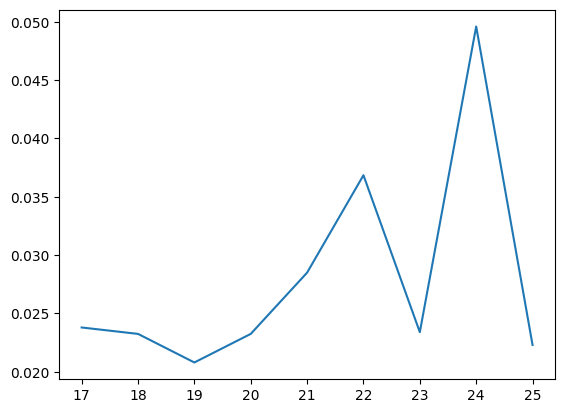

In [95]:
years = sorted(dates.keys())
point_id = 0

b2_values = [df_dict[dates[y][0]]['B2'][0] for y in years]

import matplotlib.pyplot as plt
plt.plot(years, b2_values)

In [96]:
import pandas as pd

for start, end in dates.values():
    df_dict[start]['start_date'] = start
    df_dict[start]['end_date'] = end

combined_df = pd.concat(df_dict.values(), ignore_index=True)
combined_df.to_csv("combined_df.csv", index=False)

In [ ]:
bands = ["B2", "B3", "B4", "B8"]

roi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])
points = samples.map(lambda f: f.set("point_id", f.get("system:index")))

start = ee.Date("2024-01-01")#17
end = ee.Date("2026-01-01")

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi)
    .filterDate(start, end)
    #.filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    #.map(mask_s2_clouds)
    .select(bands)
)

n_months = end.difference(start, "month").toInt()

def sample_one_month(offset):
    offset = ee.Number(offset)
    month_start = start.advance(offset, "month")
    month_end = month_start.advance(1, "month")
    month_ic = s2.filterDate(month_start, month_end)

    def sampled():
        img = month_ic.median()

        # Optional later:
        # img = img.addBands(
        #     img.normalizedDifference(["B8", "B4"]).rename("NDVI")
        # )

        return img.sampleRegions(
            collection=points,
            properties=["point_id"],
            scale=10,
            geometries=False,
        ).map(lambda f: f.set({
            "date": month_start.format("YYYY-MM-01"),
            "year": month_start.get("year"),
            "month": month_start.get("month"),
        }))

    return ee.FeatureCollection(
        ee.Algorithms.If(month_ic.size().gt(0), sampled(), ee.FeatureCollection([]))
    )

monthly_samples = ee.FeatureCollection(
    ee.List.sequence(0, n_months.subtract(1)).map(sample_one_month)
).flatten()

df = ee.data.computeFeatures({
    "expression": monthly_samples,
    "fileFormat": "PANDAS_DATAFRAME",
})

In [101]:
df.to_csv("monthly_samples.csv", index=False)

In [11]:
samples.size().getInfo()

10

In [15]:
bands = ["B2", "B3", "B4", "B8"]

points = samples.map(lambda f: f.set("point_id", f.get("system:index")))

ic = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi)
    .filterDate("2024-01-01", "2026-01-01")
    #.select(bands)
)

def sample_image(image):
    date_str = image.date().format("YYYY-MM-dd")
    timestamp = image.get("system:time_start")

    fc = image.sampleRegions(
        collection=samples,
        properties=["point_id"],
        scale=10,
        geometries=False,
    )
    return fc.map(lambda f: f.set({
        "date": date_str,
        "timestamp": timestamp,
        "image_id": image.id(),
    }))

all_samples = ee.FeatureCollection(ic.map(sample_image)).flatten()

df = ee.data.computeFeatures({
    "expression": all_samples,
    "fileFormat": "PANDAS_DATAFRAME",
})

In [15]:
points = samples.map(lambda f: f.set("point_id", f.get("system:index")))

ic = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(points.geometry())
    .filterDate("2017-01-01", "2026-01-01")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .map(mask_s2_clouds)
)

def accumulate_samples(image, acc):
    image = ee.Image(image)
    acc = ee.FeatureCollection(acc)

    sampled = (
        image
        .unmask(-9999)  # remove this line if you only want valid observations
        .sampleRegions(
            collection=points,
            properties=["point_id"],
            scale=10,
            geometries=False,
        )
        .map(lambda f: f.set({
            "date": image.date().format("YYYY-MM-dd"),
            "timestamp": image.get("system:time_start"),
            "image_id": image.get("system:index"),
        }))
    )

    return acc.merge(sampled)

all_samples = ee.FeatureCollection(
    ic.iterate(accumulate_samples, ee.FeatureCollection([]))
)

df = ee.data.computeFeatures({
    "expression": all_samples,
    "fileFormat": "PANDAS_DATAFRAME",
})

NameError: name 'samples' is not defined

In [26]:
all_samples.size().getInfo()

2573

In [27]:
df.head(5)

,geo,AOT,B1,B11,B12,B2,B3,B4,B5,B6,...,QA60,SCL,TCI_B,TCI_G,TCI_R,WVP,date,image_id,point_id,timestamp
0,None,0.0114,0.0164,0.1466,0.0873,0.0148,0.0228,0.0356,0.0702,0.1164,...,0,0.0004,0.0016,0.0024,0.0037,0.0434,2017-01-27,20170127T102301_20170127T102258_T32UNE,0,1485512758628
1,None,0.0114,0.1341,0.1211,0.0855,0.1744,0.1964,0.2002,0.2445,0.3245,...,0,0.0005,0.0178,0.0200,0.0204,0.0579,2017-01-27,20170127T102301_20170127T102258_T32UNE,2,1485512758628
2,None,0.0114,0.0257,0.1406,0.0869,0.0069,0.0226,0.0283,0.0673,0.1038,...,0,0.0005,0.0008,0.0023,0.0029,0.0380,2017-01-27,20170127T102301_20170127T102258_T32UNE,9,1485512758628
3,None,0.0114,0.0199,0.1450,0.0864,0.0167,0.0238,0.0359,0.0697,0.1153,...,0,0.0004,0.0011,0.0026,0.0037,0.0435,2017-01-27,20170127T102301_20170127T102258_T32UPE,0,1485512753253
4,None,0.0114,0.0103,0.1210,0.0766,0.0092,0.0202,0.0234,0.0528,0.0776,...,0,0.0005,0.0010,0.0022,0.0024,0.0300,2017-01-27,20170127T102301_20170127T102258_T32UPE,4,1485512753253


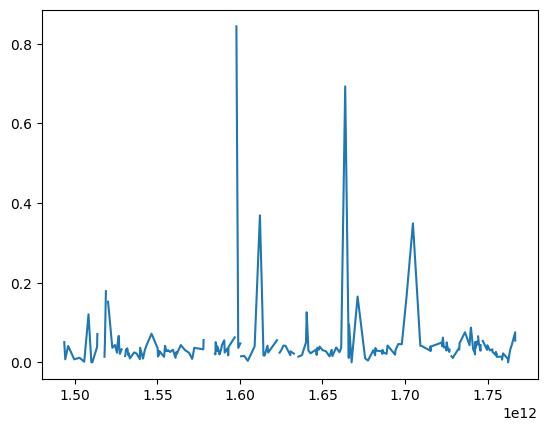

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
point_1 = df[df["point_id"] == "1"].sort_values("timestamp").replace(-9999, np.nan)
cloud_prob_mask = point_1["MSK_CLASSI_OPAQUE"] > 0.1
plt.plot(point_1["timestamp"], point_1["B2"])
plt.scatter(point_1["timestamp"][cloud_prob_mask], point_1["MSK_CLASSI_OPAQUE"][cloud_prob_mask])

In [21]:
ic = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(samples.geometry())
    .filterDate("2026-01-01", "2026-01-10")
    #.select(bands)
)

display(ic.toBands().getInfo())

{'type': 'Image',
 'bands': [{'id': '20260103T103441_20260103T103437_T32UNE_B1',
   'data_type': {'type': 'PixelType',
    'precision': 'int',
    'min': 0,
    'max': 65535},
   'dimensions': [1830, 1830],
   'crs': 'EPSG:32632',
   'crs_transform': [60, 0, 499980, 0, -60, 6000000]},
  {'id': '20260103T103441_20260103T103437_T32UNE_B2',
   'data_type': {'type': 'PixelType',
    'precision': 'int',
    'min': 0,
    'max': 65535},
   'dimensions': [10980, 10980],
   'crs': 'EPSG:32632',
   'crs_transform': [10, 0, 499980, 0, -10, 6000000]},
  {'id': '20260103T103441_20260103T103437_T32UNE_B3',
   'data_type': {'type': 'PixelType',
    'precision': 'int',
    'min': 0,
    'max': 65535},
   'dimensions': [10980, 10980],
   'crs': 'EPSG:32632',
   'crs_transform': [10, 0, 499980, 0, -10, 6000000]},
  {'id': '20260103T103441_20260103T103437_T32UNE_B4',
   'data_type': {'type': 'PixelType',
    'precision': 'int',
    'min': 0,
    'max': 65535},
   'dimensions': [10980, 10980],
   'crs': 

In [8]:
from datetime import datetime
m = geemap.Map()
x_center = 10.412417373993579
y_center = 53.50720666753097
m.set_center(x_center, y_center, 12)
styled = samples.style(
    color='000000FF',
    fillColor='00000000',
    styleProperty='style',
    neighborhood=6,  # increase to correctly draw large points
)
m.add_layer(styled)
m.add_layer(roi, {}, 'ROI')

image = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2020-03-01', '2020-03-05')
    .filterBounds(roi)
    .first()
    .divide(10000)
)
visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B4', 'B3', 'B2'],
}
m.add_layer(image, visualization, 'RGB')
display(m)

NameError: name 'samples' is not defined

In [7]:
def image_map(image):
    return image.divide(10000)

xmin, ymin, xmax, ymax = 10.4, 53.5, 10.8, 53.7

roi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])

dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2020-05-04', '2020-07-15')
    .filterBounds(roi)
    .map(image_map)
)
print(dataset.elementType)

visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B4', 'B3', 'B2'],
}

m = geemap.Map()
m.set_center(xmin, ymin, 12)
m.add_layer(dataset.min(), visualization, 'RGB')
m

<function ImageCollection.elementType at 0x110462980>


Map(center=[53.5, 10.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [13]:
import numpy as np
x, y = 10.7805, 53.5591
p = ee.Geometry.Point(x, y)
x_r, y_r = 10, 53.56
p_r = ee.Geometry.Point(x_r, y_r)

min_x, max_x, min_y, max_y = 9.5, 11, 53, 54
gen = np.random.default_rng(1)
n_samples = 10
x = gen.uniform(min_x, max_x, size=n_samples)
y = gen.uniform(min_y, max_y, size=n_samples)
point_list = [ee.Geometry.Point(x[i], y[i]) for i in range(n_samples)]

point_collection = ee.featurecollection.FeatureCollection(point_list).map(lambda f: f.set("point_id", f.id()))
radius = 1#0.04
region_around_p = ee.Geometry.BBox(west=min_x, east=max_x, south=min_y, north=max_y)
m = geemap.Map()
styled = point_collection.style(
    color='000000FF',
    fillColor='00000000',
    styleProperty='style',
    neighborhood=6,  # increase to correctly draw large points
)
m.add_layer(styled)
m.add_layer(region_around_p)
m.set_center((min_x + max_x)/2, (min_y + max_y)/2, zoom=14)
m


Map(center=[53.5, 10.25], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [14]:
ic = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(point_collection.geometry())
    .filterDate("2024-12-01", "2026-01-01")
)

def accumulate_samples(image, acc):
    image = ee.Image(image)
    acc = ee.FeatureCollection(acc)

    sampled = (
        image
        .unmask(-9999)  # remove this line if you only want valid observations
        .sampleRegions(
            collection=point_collection,
            properties=["point_id"],
            scale=10,
            geometries=False,
        )
        .map(lambda f: f.set({
            "date": image.date().format("YYYY-MM-dd"),
            "timestamp": image.get("system:time_start"),
            "image_id": image.get("system:index"),
        }))
    )

    return acc.merge(sampled)

all_samples = ee.FeatureCollection(
    ic.iterate(accumulate_samples, ee.FeatureCollection([]))
)

df = ee.data.computeFeatures({
    "expression": all_samples,
    "fileFormat": "PANDAS_DATAFRAME",
})
print(df.head())

    geo  AOT   B1   B11  B12   B2   B3   B4    B5    B6  ...  QA60  SCL  \
0  None   90  518  1394  854  525  678  430  1099  2205  ...     0    4   
1  None  102  474  1395  854  491  656  412  1091  2207  ...     0    4   
2  None   90  371  1260  591  507  791  345  1467  3958  ...     0    4   
3  None  108  298  1585  858  462  638  387  1143  2416  ...     0    4   
4  None  108  626  1399  761  601  907  575  1390  3010  ...     0    4   

   TCI_B  TCI_G  TCI_R   WVP        date  \
0     54     69     44   665  2024-12-01   
1     50     67     42   668  2024-12-01   
2     52     81     36   674  2024-12-01   
3     46     65     39   699  2024-12-01   
4     62     93     59  1007  2024-12-01   

                                 image_id  point_id      timestamp  
0  20241201T102319_20241201T102552_T32UND         8  1733048779436  
1  20241201T102319_20241201T102552_T32UNE         8  1733048766852  
2  20241201T102319_20241201T102552_T32UPD         6  1733048776022  
3  20241

In [16]:
print(df.shape)
df.to_csv('monthly_samples.csv')

(1914, 31)


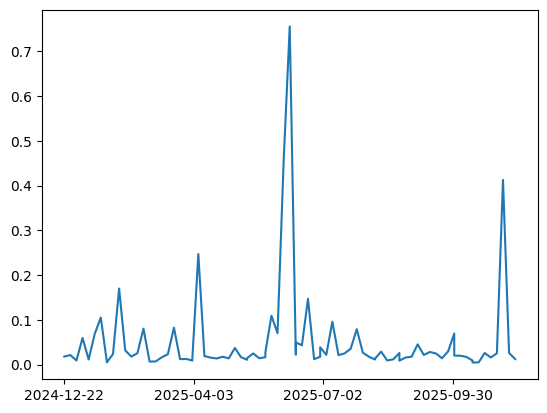

In [9]:
import matplotlib.pyplot as plt
mask = (df['MSK_CLDPRB']/100 < 0.1) * (df['point_id'] == '1')
df_masked = df[mask]
plt.plot(df_masked['date'], df_masked['B4']/10000)
plt.plot
n_ticks = 4
ticks = [len(df_masked) * i / n_ticks for i in range(n_ticks)]
plt.xticks(ticks)#[0, 50, 100, 150])
plt.show()